In [2]:
import pandas as pd

log_file = "../data/Apache_2k.log"

with open(log_file, "r") as f:
    logs = f.readlines()

print("Total log entries:", len(logs))
print("\nSample logs:")
logs[:5]


Total log entries: 2000

Sample logs:


['[Sun Dec 04 04:47:44 2005] [notice] workerEnv.init() ok /etc/httpd/conf/workers2.properties\n',
 '[Sun Dec 04 04:47:44 2005] [error] mod_jk child workerEnv in error state 6\n',
 '[Sun Dec 04 04:51:08 2005] [notice] jk2_init() Found child 6725 in scoreboard slot 10\n',
 '[Sun Dec 04 04:51:09 2005] [notice] jk2_init() Found child 6726 in scoreboard slot 8\n',
 '[Sun Dec 04 04:51:09 2005] [notice] jk2_init() Found child 6728 in scoreboard slot 6\n']

In [3]:
errors = [log for log in logs if "[error]" in log.lower()]
print("Total error events:", len(errors))
errors[:5]


Total error events: 595


['[Sun Dec 04 04:47:44 2005] [error] mod_jk child workerEnv in error state 6\n',
 '[Sun Dec 04 04:51:18 2005] [error] mod_jk child workerEnv in error state 6\n',
 '[Sun Dec 04 04:51:18 2005] [error] mod_jk child workerEnv in error state 6\n',
 '[Sun Dec 04 04:51:18 2005] [error] mod_jk child workerEnv in error state 6\n',
 '[Sun Dec 04 04:51:55 2005] [error] mod_jk child workerEnv in error state 6\n']

In [4]:
from collections import Counter

error_types = Counter(errors)
error_types.most_common(5)


[('[Sun Dec 04 17:01:47 2005] [error] mod_jk child workerEnv in error state 6\n',
  5),
 ('[Sun Dec 04 19:36:07 2005] [error] mod_jk child workerEnv in error state 6\n',
  5),
 ('[Sun Dec 04 05:04:04 2005] [error] mod_jk child workerEnv in error state 7\n',
  4),
 ('[Sun Dec 04 07:18:00 2005] [error] mod_jk child workerEnv in error state 7\n',
  4),
 ('[Sun Dec 04 16:41:22 2005] [error] mod_jk child workerEnv in error state 6\n',
  4)]

In [5]:
import re

clean_errors = [re.sub(r"\[.*?\]\s*", "", log) for log in errors]
Counter(clean_errors).most_common(5)


[('mod_jk child workerEnv in error state 6\n', 368),
 ('mod_jk child workerEnv in error state 7\n', 101),
 ('mod_jk child workerEnv in error state 8\n', 44),
 ('Directory index forbidden by rule: /var/www/html/\n', 32),
 ('mod_jk child workerEnv in error state 9\n', 20)]

In [6]:
forbidden = [log for log in logs if "forbidden" in log.lower()]
print("Forbidden access attempts:", len(forbidden))
forbidden[:10]


Forbidden access attempts: 32


['[Sun Dec 04 05:15:09 2005] [error] [client 222.166.160.184] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 07:45:45 2005] [error] [client 63.13.186.196] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 08:54:17 2005] [error] [client 147.31.138.75] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 09:35:12 2005] [error] [client 207.203.80.15] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 10:53:30 2005] [error] [client 218.76.139.20] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 11:11:07 2005] [error] [client 24.147.151.74] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 11:33:18 2005] [error] [client 211.141.93.88] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 11:42:43 2005] [error] [client 216.127.124.16] Directory index forbidden by rule: /var/www/html/\n',
 '[Sun Dec 04 12:33:13 2005] [error] [client 208.51.151.210] Directory index forbidde

In [7]:
# Extract attacker IPs from forbidden logs
import re
from collections import Counter

ips = []
for log in forbidden:
    match = re.search(r"\[client (.*?)\]", log)
    if match:
        ips.append(match.group(1))

Counter(ips).most_common(10)


[('222.166.160.184', 1),
 ('63.13.186.196', 1),
 ('147.31.138.75', 1),
 ('207.203.80.15', 1),
 ('218.76.139.20', 1),
 ('24.147.151.74', 1),
 ('211.141.93.88', 1),
 ('216.127.124.16', 1),
 ('208.51.151.210', 1),
 ('65.68.235.27', 1)]

In [8]:
# Build simple threat scoring model

threat_scores = {}

for ip in ips:
    score = 0
    
    # base score for forbidden access attempt
    score += 5
    
    threat_scores[ip] = score

threat_scores


{'222.166.160.184': 5,
 '63.13.186.196': 5,
 '147.31.138.75': 5,
 '207.203.80.15': 5,
 '218.76.139.20': 5,
 '24.147.151.74': 5,
 '211.141.93.88': 5,
 '216.127.124.16': 5,
 '208.51.151.210': 5,
 '65.68.235.27': 5,
 '4.245.93.87': 5,
 '67.154.58.130': 5,
 '24.83.37.136': 5,
 '58.225.62.140': 5,
 '61.138.216.82': 5,
 '218.39.132.175': 5,
 '125.30.38.52': 5,
 '61.37.222.240': 5,
 '218.62.18.218': 5,
 '211.62.201.48': 5,
 '218.207.61.7': 5,
 '168.20.198.21': 5,
 '221.232.178.24': 5,
 '207.12.15.211': 5,
 '141.153.150.164': 5,
 '198.232.168.9': 5,
 '67.166.248.235': 5,
 '141.154.18.244': 5,
 '216.216.185.130': 5,
 '218.75.106.250': 5,
 '68.228.3.15': 5,
 '61.220.139.68': 5}

In [9]:
import pandas as pd

df = pd.DataFrame(list(threat_scores.items()), columns=["IP", "Threat_Score"])
df


,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5
5,24.147.151.74,5
6,211.141.93.88,5
7,216.127.124.16,5
8,208.51.151.210,5
9,65.68.235.27,5


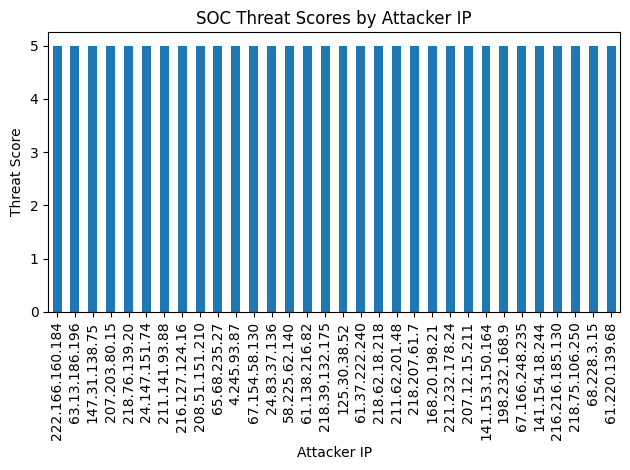

In [10]:
import matplotlib.pyplot as plt

df.plot(kind="bar", x="IP", y="Threat_Score", legend=False)
plt.title("SOC Threat Scores by Attacker IP")
plt.ylabel("Threat Score")
plt.xlabel("Attacker IP")
plt.tight_layout()
plt.show()


In [11]:
# Smarter threat scoring
threat_scores = {}

for ip, count in Counter(ips).items():
    score = 0
    
    if count >= 3:
        score += 10   # repeated attacker
    else:
        score += 5    # single attempt
    
    threat_scores[ip] = score

df = pd.DataFrame(list(threat_scores.items()), columns=["IP", "Threat_Score"])
df.sort_values("Threat_Score", ascending=False)


,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5
5,24.147.151.74,5
6,211.141.93.88,5
7,216.127.124.16,5
8,208.51.151.210,5
9,65.68.235.27,5


In [12]:
from collections import Counter
import pandas as pd

# Count how many times each IP appears
ip_counts = Counter(ips)

threat_scores = {}

for ip, count in ip_counts.items():
    score = 0
    
    if count >= 5:
        score += 20   # high risk
    elif count >= 3:
        score += 10   # medium risk
    else:
        score += 5    # low risk
    
    threat_scores[ip] = score

df = pd.DataFrame(list(threat_scores.items()), columns=["IP", "Threat_Score"])
df = df.sort_values("Threat_Score", ascending=False)
df


,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5
5,24.147.151.74,5
6,211.141.93.88,5
7,216.127.124.16,5
8,208.51.151.210,5
9,65.68.235.27,5


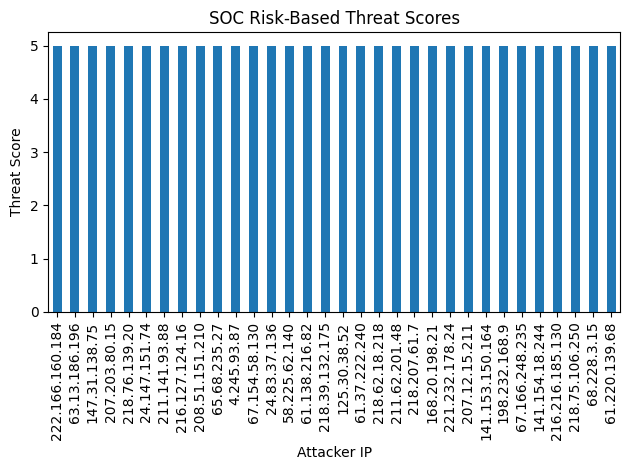

In [13]:
import matplotlib.pyplot as plt

df.plot(kind="bar", x="IP", y="Threat_Score", legend=False)
plt.title("SOC Risk-Based Threat Scores")
plt.ylabel("Threat Score")
plt.xlabel("Attacker IP")
plt.tight_layout()
plt.show()


In [14]:
# Improved threat scoring based on frequency
from collections import Counter

# Count how many times each IP appears
ip_counts = Counter(ips)

# New smarter threat scores
smart_scores = {}
for ip, count in ip_counts.items():
    smart_scores[ip] = count * 5   # more attempts = higher risk

# Convert to DataFrame
df_smart = pd.DataFrame(list(smart_scores.items()), 
                        columns=["IP", "Threat_Score"])

df_smart.sort_values("Threat_Score", ascending=False)


,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5
5,24.147.151.74,5
6,211.141.93.88,5
7,216.127.124.16,5
8,208.51.151.210,5
9,65.68.235.27,5


In [15]:
# SMART threat scoring based on frequency
from collections import Counter

# Count how many times each IP attacked
ip_counts = Counter(ips)

smart_scores = {}
for ip, count in ip_counts.items():
    smart_scores[ip] = count * 5   # more attempts = higher risk

# New smart DataFrame
df_smart = pd.DataFrame(
    list(smart_scores.items()),
    columns=["IP", "Threat_Score"]
)

df_smart.sort_values("Threat_Score", ascending=False)


,IP,Threat_Score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5
5,24.147.151.74,5
6,211.141.93.88,5
7,216.127.124.16,5
8,208.51.151.210,5
9,65.68.235.27,5


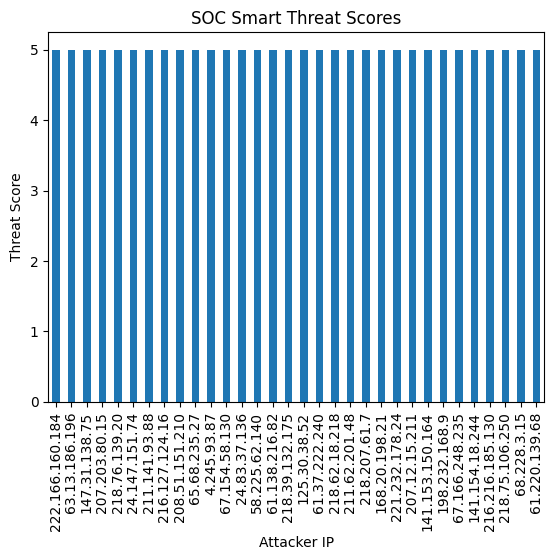

In [16]:
df_smart.plot(kind="bar", x="IP", y="Threat_Score", legend=False)
plt.title("SOC Smart Threat Scores")
plt.ylabel("Threat Score")
plt.xlabel("Attacker IP")
plt.show()


In [17]:
def label_risk(score):
    if score >= 20:
        return "High"
    elif score >= 10:
        return "Medium"
    else:
        return "Low"

df_smart["Risk_Level"] = df_smart["Threat_Score"].apply(label_risk)
df_smart


,IP,Threat_Score,Risk_Level
0,222.166.160.184,5,Low
1,63.13.186.196,5,Low
2,147.31.138.75,5,Low
3,207.203.80.15,5,Low
4,218.76.139.20,5,Low
5,24.147.151.74,5,Low
6,211.141.93.88,5,Low
7,216.127.124.16,5,Low
8,208.51.151.210,5,Low
9,65.68.235.27,5,Low


In [18]:
# Smarter threat scoring model
from collections import Counter

ip_counts = Counter(ips)
smart_scores = {}

for ip, count in ip_counts.items():
    score = 0
    
    # Frequency-based scoring
    if count >= 5:
        score += 10
    elif count >= 3:
        score += 7
    else:
        score += 4
    
    smart_scores[ip] = score

smart_scores


{'222.166.160.184': 4,
 '63.13.186.196': 4,
 '147.31.138.75': 4,
 '207.203.80.15': 4,
 '218.76.139.20': 4,
 '24.147.151.74': 4,
 '211.141.93.88': 4,
 '216.127.124.16': 4,
 '208.51.151.210': 4,
 '65.68.235.27': 4,
 '4.245.93.87': 4,
 '67.154.58.130': 4,
 '24.83.37.136': 4,
 '58.225.62.140': 4,
 '61.138.216.82': 4,
 '218.39.132.175': 4,
 '125.30.38.52': 4,
 '61.37.222.240': 4,
 '218.62.18.218': 4,
 '211.62.201.48': 4,
 '218.207.61.7': 4,
 '168.20.198.21': 4,
 '221.232.178.24': 4,
 '207.12.15.211': 4,
 '141.153.150.164': 4,
 '198.232.168.9': 4,
 '67.166.248.235': 4,
 '141.154.18.244': 4,
 '216.216.185.130': 4,
 '218.75.106.250': 4,
 '68.228.3.15': 4,
 '61.220.139.68': 4}

In [19]:
df2 = pd.DataFrame(list(smart_scores.items()), 
                   columns=["IP", "Threat_Score"])
df2


,IP,Threat_Score
0,222.166.160.184,4
1,63.13.186.196,4
2,147.31.138.75,4
3,207.203.80.15,4
4,218.76.139.20,4
5,24.147.151.74,4
6,211.141.93.88,4
7,216.127.124.16,4
8,208.51.151.210,4
9,65.68.235.27,4


In [20]:
def classify(score):
    if score >= 10:
        return "High"
    elif score >= 7:
        return "Medium"
    else:
        return "Low"

df2["Risk_Level"] = df2["Threat_Score"].apply(classify)
df2


,IP,Threat_Score,Risk_Level
0,222.166.160.184,4,Low
1,63.13.186.196,4,Low
2,147.31.138.75,4,Low
3,207.203.80.15,4,Low
4,218.76.139.20,4,Low
5,24.147.151.74,4,Low
6,211.141.93.88,4,Low
7,216.127.124.16,4,Low
8,208.51.151.210,4,Low
9,65.68.235.27,4,Low


In [21]:
import pandas as pd
import numpy as np

CFG = {
    "time": "timestamp",
    "src": "src_ip",
    "dst": "dst_ip",
    "user": "user",          # set to None if you don't have it
    "status": "status",      # e.g. "FAIL"/"SUCCESS"/"BLOCKED"/"ALLOWED"
    "event": "event_type",   # e.g. "auth", "firewall", "ids"
    "score": "threat_score"
}

df = df.copy()
df[CFG["time"]] = pd.to_datetime(df[CFG["time"]], errors="coerce")
df = df.dropna(subset=[CFG["time"], CFG["src"]]).sort_values(CFG["time"])

def is_fail(x):
    if pd.isna(x): return False
    s = str(x).lower()
    return ("fail" in s) or ("invalid" in s) or ("denied" in s)

def is_success(x):
    if pd.isna(x): return False
    s = str(x).lower()
    return ("success" in s) or ("accepted" in s) or ("logged in" in s)

df["is_fail"] = df[CFG["status"]].apply(is_fail) if CFG["status"] in df.columns else False
df["is_success"] = df[CFG["status"]].apply(is_success) if CFG["status"] in df.columns else False

# --- Brute force: many fails from same src within a short window ---
WINDOW = "10min"
FAIL_THRESHOLD = 12

fails = df[df["is_fail"]].copy()
fails["fail_count_10m"] = (
    fails.set_index(CFG["time"])
         .groupby(CFG["src"])["is_fail"]
         .rolling(WINDOW).sum()
         .reset_index(level=0, drop=True)
         .values
)
df = df.merge(
    fails[[CFG["time"], CFG["src"], "fail_count_10m"]],
    on=[CFG["time"], CFG["src"]],
    how="left"
)
df["fail_count_10m"] = df["fail_count_10m"].fillna(0)

df["det_bruteforce"] = df["fail_count_10m"] >= FAIL_THRESHOLD

# --- Password spray: one src fails against many users in window (if user exists) ---
if CFG["user"] and CFG["user"] in df.columns:
    spray = df[df["is_fail"]].copy()
    spray["users_targeted_30m"] = (
        spray.set_index(CFG["time"])
             .groupby(CFG["src"])[CFG["user"]]
             .rolling("30min")
             .apply(lambda s: s.nunique(), raw=False)
             .reset_index(level=0, drop=True)
             .values
    )
    df = df.merge(
        spray[[CFG["time"], CFG["src"], "users_targeted_30m"]],
        on=[CFG["time"], CFG["src"]],
        how="left"
    )
    df["users_targeted_30m"] = df["users_targeted_30m"].fillna(0)
    df["det_password_spray"] = df["users_targeted_30m"] >= 8
else:
    df["users_targeted_30m"] = 0
    df["det_password_spray"] = False

# --- Port scan-ish: one src touches many dst ports in window (if you have dst_port) ---
if "dst_port" in df.columns:
    scan = df.copy()
    scan["ports_5m"] = (
        scan.set_index(CFG["time"])
            .groupby(CFG["src"])["dst_port"]
            .rolling("5min")
            .apply(lambda s: s.nunique(), raw=False)
            .reset_index(level=0, drop=True)
            .values
    )
    df["ports_5m"] = scan["ports_5m"].fillna(0)
    df["det_port_scan"] = df["ports_5m"] >= 20
else:
    df["ports_5m"] = 0
    df["det_port_scan"] = False

# --- Simple "lateral movement" signal: one src accesses many internal dst hosts quickly (if you have dst_ip) ---
if CFG["dst"] in df.columns:
    lat = df.copy()
    lat["unique_dst_10m"] = (
        lat.set_index(CFG["time"])
           .groupby(CFG["src"])[CFG["dst"]]
           .rolling("10min")
           .apply(lambda s: s.nunique(), raw=False)
           .reset_index(level=0, drop=True)
           .values
    )
    df["unique_dst_10m"] = lat["unique_dst_10m"].fillna(0)
    df["det_lateral_movement"] = df["unique_dst_10m"] >= 15
else:
    df["unique_dst_10m"] = 0
    df["det_lateral_movement"] = False


KeyError: 'timestamp'

In [22]:
df.columns.tolist()


['IP', 'Threat_Score']

In [23]:
import pandas as pd
import numpy as np
import ipaddress

df = df.copy()

# Standardize column names (keep originals too if you want)
df.rename(columns={"IP": "ip", "Threat_Score": "threat_score"}, inplace=True)

# Coerce threat_score to numeric
df["threat_score"] = pd.to_numeric(df["threat_score"], errors="coerce")
df = df.dropna(subset=["ip", "threat_score"])

# Validate IPs
def valid_ip(x):
    try:
        ipaddress.ip_address(str(x).strip())
        return True
    except Exception:
        return False

df["ip_valid"] = df["ip"].apply(valid_ip)
df = df[df["ip_valid"]].drop(columns=["ip_valid"])

df.head()


,ip,threat_score
0,222.166.160.184,5
1,63.13.186.196,5
2,147.31.138.75,5
3,207.203.80.15,5
4,218.76.139.20,5


In [24]:
import pandas as pd

df["severity"] = pd.cut(
    df["threat_score"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Medium", "High", "Critical"]
)

df.head()


,ip,threat_score,severity
0,222.166.160.184,5,Very Low
1,63.13.186.196,5,Very Low
2,147.31.138.75,5,Very Low
3,207.203.80.15,5,Very Low
4,218.76.139.20,5,Very Low


In [25]:
def reason(score):
    if score >= 80:
        return "High-risk IP (multiple malicious indicators)"
    elif score >= 60:
        return "Suspicious behavior detected"
    elif score >= 40:
        return "Moderate anomaly score"
    else:
        return "Low confidence / background noise"

df["reason"] = df["threat_score"].apply(reason)
df.head()


,ip,threat_score,severity,reason
0,222.166.160.184,5,Very Low,Low confidence / background noise
1,63.13.186.196,5,Very Low,Low confidence / background noise
2,147.31.138.75,5,Very Low,Low confidence / background noise
3,207.203.80.15,5,Very Low,Low confidence / background noise
4,218.76.139.20,5,Very Low,Low confidence / background noise


In [26]:
kpis = {
    "Total IPs": len(df),
    "Critical IPs": (df["severity"] == "Critical").sum(),
    "High IPs": (df["severity"] == "High").sum(),
    "Average Score": round(df["threat_score"].mean(), 2),
    "Max Score": df["threat_score"].max()
}
kpis


{'Total IPs': 32,
 'Critical IPs': np.int64(0),
 'High IPs': np.int64(0),
 'Average Score': np.float64(5.0),
 'Max Score': np.int64(5)}

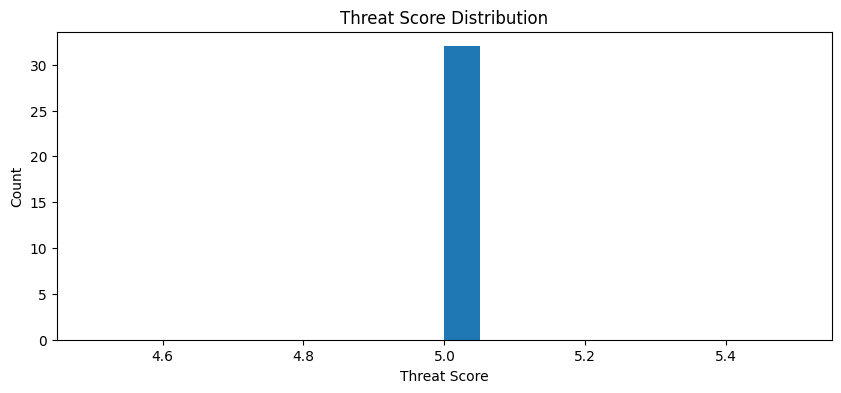

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df["threat_score"], bins=20)
plt.title("Threat Score Distribution")
plt.xlabel("Threat Score")
plt.ylabel("Count")
plt.show()


In [28]:
top_alerts.to_csv("soc_alerts_top20.csv", index=False)
df.to_json("soc_ip_risk_feed.json", orient="records")


NameError: name 'top_alerts' is not defined

In [29]:
top_alerts = df.sort_values("threat_score", ascending=False).head(20)
top_alerts


,ip,threat_score,severity,reason
0,222.166.160.184,5,Very Low,Low confidence / background noise
1,63.13.186.196,5,Very Low,Low confidence / background noise
2,147.31.138.75,5,Very Low,Low confidence / background noise
3,207.203.80.15,5,Very Low,Low confidence / background noise
4,218.76.139.20,5,Very Low,Low confidence / background noise
5,24.147.151.74,5,Very Low,Low confidence / background noise
6,211.141.93.88,5,Very Low,Low confidence / background noise
7,216.127.124.16,5,Very Low,Low confidence / background noise
8,208.51.151.210,5,Very Low,Low confidence / background noise
9,65.68.235.27,5,Very Low,Low confidence / background noise


In [31]:
top_alerts.to_csv("soc_alerts_top20.csv", index=False)
df.to_json("soc_ip_risk_feed.json", orient="records")


In [32]:
parsed_df.columns.tolist()


NameError: name 'parsed_df' is not defined

In [33]:
globals().keys()


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'log_file', 'f', 'logs', '_2', '_i3', 'errors', '_3', '_i4', 'Counter', 'error_types', '_4', '_i5', 're', 'clean_errors', '_5', '_i6', 'forbidden', '_6', '_i7', 'ips', 'log', 'match', '_7', '_i8', 'threat_scores', 'ip', 'score', '_8', '_i9', 'df', '_9', '_i10', 'plt', '_i11', 'count', '_11', '_i12', 'ip_counts', '_12', '_i13', '_i14', 'smart_scores', 'df_smart', '_14', '_i15', '_15', '_i16', '_i17', 'label_risk', '_17', '_i18', '_18', '_i19', 'df2', '_19', '_i20', 'classify', '_20', '_i21', 'np', 'CFG', '_i22', '_22', '_i23', 'ipaddress', 'valid_ip', '_23', '_i24', '_24', '_i25', 'reason', '_25', '_i26', 'kpis', '_26', '_i27', '_i28', '_i29', 'top_alerts', '_29', '_i30', '_i31', '_i32', '_i33'])